<a href="https://colab.research.google.com/github/Adrian53zz/MachineLearning/blob/main/Proyecto1_Unidad4_Segmentacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentación de Pacientes con K-Means y PCA
**Proyecto 1 — Unidad 4**  
Objetivo: Aplicar K-Means y PCA para identificar perfiles de pacientes según características cardiovasculares.


## 1. Importaciones y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## 2. Carga y exploración del dataset

### 2.1 Descripción de variables
El dataset contiene **6 000 pacientes** con 16 variables clínicas, demográficas y de hábitos.
Para el clustering se utilizan **exclusivamente** las 4 variables clínicas indicadas en el proyecto:

| Variable | Descripción |
|---|---|
| `blood_pressure` | Presión arterial en reposo (mm Hg) |
| `cholesterol` | Colesterol sérico (mg/dl) |
| `plasma_glucose` | Glucosa en plasma |
| `max_heart_rate` | Frecuencia cardíaca máxima |


In [ ]:
df = pd.read_csv("patient_dataset.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (6000, 16)


,age,gender,chest_pain_type,blood_pressure,cholesterol,max_heart_rate,exercise_angina,plasma_glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,residence_type,smoking_status
0,24,1.0,4,250,139,212,0,108.0,33.0,109.0,37.999303,0.480277,1,1,Urban,Smoker
1,29,0.0,4,132,187,147,0,202.0,42.0,NaN,25.588346,0.283986,1,1,Urban,Unknown
2,46,0.0,3,271,185,193,0,149.0,43.0,102.0,37.892029,2.472309,1,0,Rural,Non-Smoker
3,73,NaN,2,102,200,125,0,105.0,77.0,165.0,18.660241,1.472052,0,1,Rural,Smoker
4,49,1.0,3,91,163,192,0,162.0,31.0,170.0,12.767980,0.537627,1,1,Rural,Smoker


In [ ]:
print("Nulos por columna:")
df.isnull().sum()

Nulos por columna:


,0
age,0
gender,472
chest_pain_type,0
blood_pressure,0
cholesterol,0
max_heart_rate,0
exercise_angina,0
plasma_glucose,609
skin_thickness,614
insulin,568


In [ ]:
df[["blood_pressure","cholesterol","plasma_glucose","max_heart_rate"]].describe()

,blood_pressure,cholesterol,plasma_glucose,max_heart_rate
count,6000.000000,6000.000000,5391.000000,6000.000000
mean,134.277167,209.844667,161.119644,144.996000
std,48.303001,52.840432,52.434693,43.583318
min,0.000000,120.000000,70.000000,70.000000
25%,109.000000,164.000000,116.000000,108.000000
50%,135.000000,210.000000,162.000000,144.000000
75%,161.000000,257.000000,206.000000,183.000000
max,300.000000,300.000000,250.000000,220.000000


## 3. Preprocesamiento
Se eliminan filas con nulos en las 4 variables clave y se aplica **StandardScaler** para que todas las variables tengan media 0 y desviación estándar 1, evitando que las de mayor magnitud dominen el clustering.

In [ ]:
features = ["blood_pressure", "cholesterol", "plasma_glucose", "max_heart_rate"]
df_clean = df[features].dropna().copy()
print(f"Registros usables: {len(df_clean):,} de {len(df):,}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
print("Estandarización aplicada (media≈0, std≈1)")


Registros usables: 5,391 de 6,000
Estandarización aplicada (media≈0, std≈1)


## 4. Análisis de Componentes Principales (PCA)
Con solo 4 variables, cada componente capta aproximadamente el **25 % de la varianza** — lo que indica que las variables no están altamente correlacionadas entre sí. Se usarán **PC1 y PC2** para visualización (≈51 % de varianza acumulada).

In [ ]:
pca_full = PCA().fit(X_scaled)
ev = pca_full.explained_variance_ratio_
cum = np.cumsum(ev)

for i,(e,c) in enumerate(zip(ev,cum)):
    print(f"PC{i+1}: {e*100:.2f}%  (acumulada: {c*100:.2f}%)")


PC1: 25.96%  (acumulada: 25.96%)
PC2: 25.21%  (acumulada: 51.17%)
PC3: 24.64%  (acumulada: 75.81%)
PC4: 24.19%  (acumulada: 100.00%)


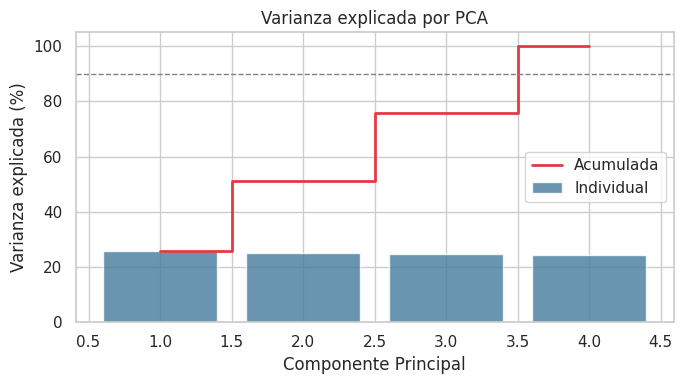

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(range(1,5), ev*100, color="#457B9D", alpha=0.8, label="Individual")
ax.step(range(1,5), cum*100, where="mid", color="#E63946", lw=2, label="Acumulada")
ax.axhline(90, ls="--", color="gray", lw=1)
ax.set_xlabel("Componente Principal"); ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza explicada por PCA"); ax.legend()
plt.tight_layout(); plt.show()


## 5. Determinación del número óptimo de clusters
Se evalúan valores de k entre 2 y 8 usando dos métricas:
- **Inercia (WCSS):** Suma de distancias cuadradas dentro de cada cluster. Buscamos el "codo".
- **Silhouette Score:** Mide qué tan bien separados están los clusters (mayor = mejor).

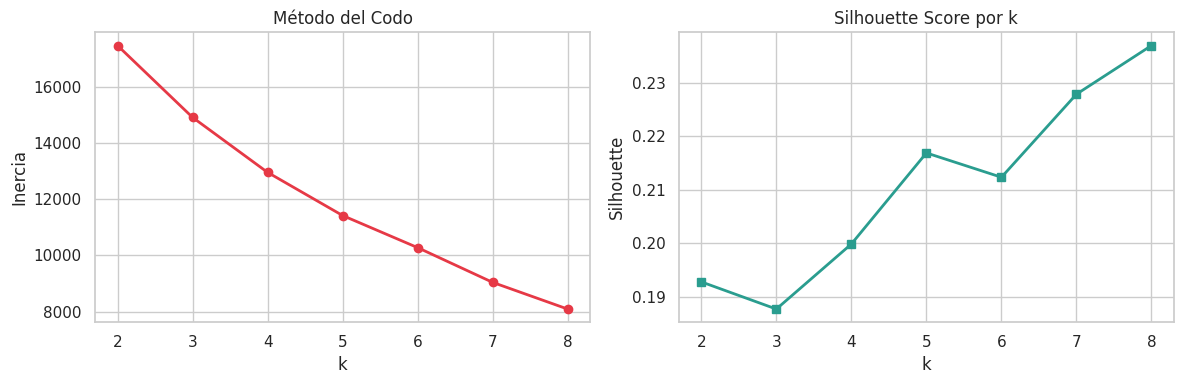

In [ ]:
inertias, silhouettes = [], []
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(range(2,9), inertias, "o-", color="#E63946", lw=2)
axes[0].set(xlabel="k", ylabel="Inercia", title="Método del Codo")
axes[1].plot(range(2,9), silhouettes, "s-", color="#2A9D8F", lw=2)
axes[1].set(xlabel="k", ylabel="Silhouette", title="Silhouette Score por k")
plt.tight_layout(); plt.show()


### 5.1 Tabla comparativa de Inercia y Silhouette
> Se elige **k = 3** por alinearse con el objetivo clínico del proyecto (bajo, medio y alto riesgo) y porque el codo sugiere una reducción de inercia significativa hasta k=3, con ganancias decrecientes después.

In [ ]:
tabla = pd.DataFrame({
    "k": range(2,9),
    "Inercia": [round(i,1) for i in inertias],
    "Silhouette": [round(s,4) for s in silhouettes]
})
tabla.set_index("k")


,Inercia,Silhouette
k,,
2,17479.6,0.1927
3,14919.4,0.1877
4,12960.4,0.1998
5,11422.7,0.2168
6,10278.9,0.2123
7,9040.9,0.2278
8,8089.5,0.2369


## 6. Entrenamiento K-Means con k = 3

In [ ]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean["cluster"] = km_final.fit_predict(X_scaled)

print("Distribución de pacientes por cluster:")
print(df_clean["cluster"].value_counts().sort_index())


Distribución de pacientes por cluster:
cluster
0    1652
1    2000
2    1739
Name: count, dtype: int64


## 7. Interpretación clínica de los clusters
Se calculan los promedios de cada variable por cluster para asignar la etiqueta de riesgo.

In [ ]:
cluster_means = df_clean.groupby("cluster")[features].mean().round(2)
print("Promedios por cluster:")
cluster_means


Promedios por cluster:


,blood_pressure,cholesterol,plasma_glucose,max_heart_rate
cluster,,,,
0,132.52,259.46,196.02,143.32
1,129.64,212.28,105.30,147.51
2,141.27,160.84,192.17,144.29


In [ ]:
# Calcular score de riesgo y etiquetar
cmz = pd.DataFrame(scaler.transform(cluster_means), index=cluster_means.index, columns=features)
risk = cmz["blood_pressure"] + cmz["cholesterol"] + cmz["plasma_glucose"] - cmz["max_heart_rate"]
ranking = risk.rank()
label_map = {i: ("Alto Riesgo" if r==3 else "Riesgo Medio" if r==2 else "Bajo Riesgo")
             for i,r in ranking.items()}
df_clean["risk_label"] = df_clean["cluster"].map(label_map)
print("Etiquetas de riesgo asignadas:")
for c,l in label_map.items():
    print(f"  Cluster {c}: {l}")


Etiquetas de riesgo asignadas:
  Cluster 0: Alto Riesgo
  Cluster 1: Bajo Riesgo
  Cluster 2: Riesgo Medio


### 7.1 Gráfica comparativa de variables por nivel de riesgo

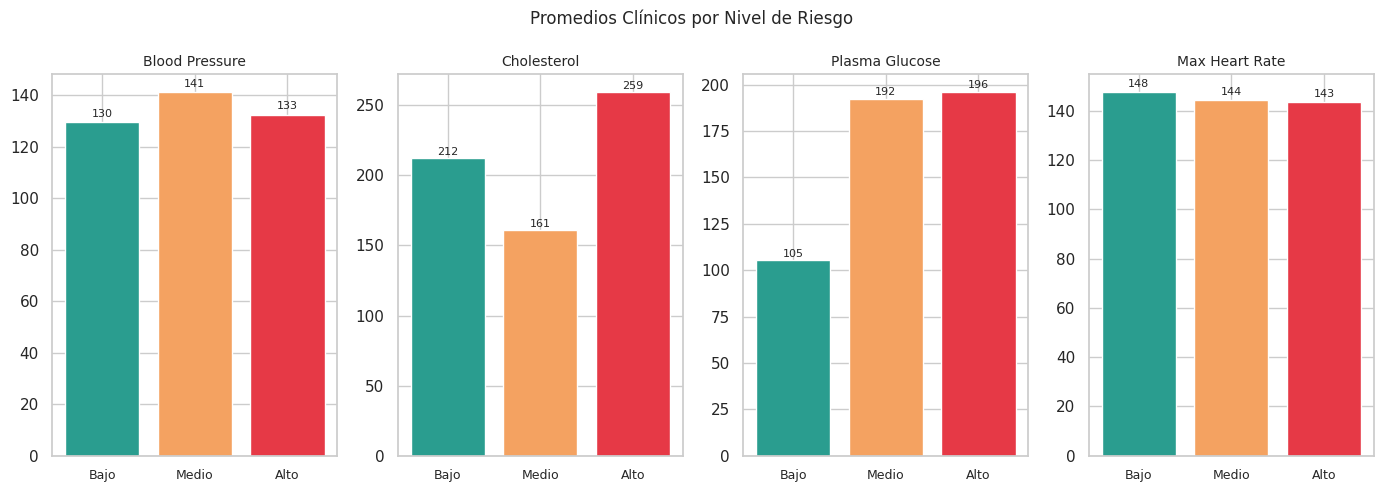

In [ ]:
color_map = {"Alto Riesgo":"#E63946","Riesgo Medio":"#F4A261","Bajo Riesgo":"#2A9D8F"}
order = ["Bajo Riesgo","Riesgo Medio","Alto Riesgo"]
fig, axes = plt.subplots(1,4,figsize=(14,5))
for ax, feat in zip(axes, features):
    vals = [df_clean[df_clean["risk_label"]==l][feat].mean() for l in order]
    bars = ax.bar(order, vals, color=[color_map[o] for o in order], edgecolor="white")
    ax.set_title(feat.replace("_"," ").title(), fontsize=10)
    ax.set_xticklabels(["Bajo","Medio","Alto"], fontsize=9)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, b.get_height()+2, f"{v:.0f}", ha="center", fontsize=8)
plt.suptitle("Promedios Clínicos por Nivel de Riesgo", fontsize=12)
plt.tight_layout(); plt.show()


## 8. Visualización PCA — Segmentación de pacientes

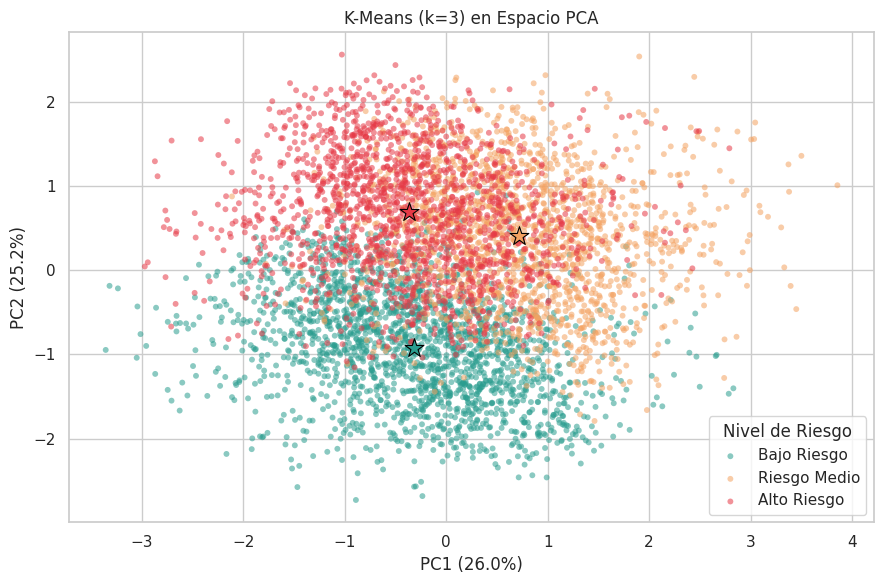

In [ ]:
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9,6))
for lbl in order:
    mask = df_clean["risk_label"] == lbl
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=color_map[lbl], label=lbl, alpha=0.55, s=18, edgecolors="none")
centers_pca = pca2.transform(km_final.cluster_centers_)
for i,(cx,cy) in enumerate(centers_pca):
    lbl = label_map[i]
    ax.scatter(cx,cy,c=color_map[lbl],s=200,marker="*",edgecolors="black",linewidths=0.8,zorder=5)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("K-Means (k=3) en Espacio PCA"); ax.legend(title="Nivel de Riesgo")
plt.tight_layout(); plt.show()


## 9. Biplot PCA — Contribución de variables

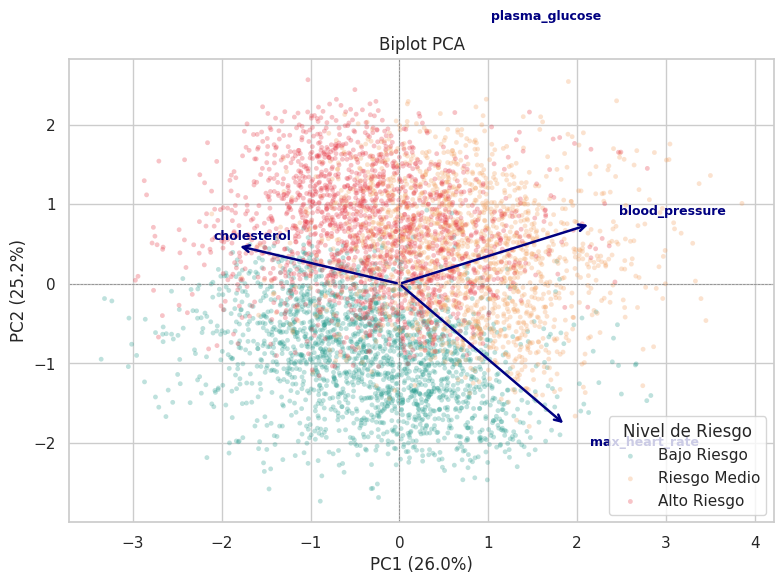

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
for lbl in order:
    mask = df_clean["risk_label"]==lbl
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=color_map[lbl], label=lbl, alpha=0.3, s=12, edgecolors="none")
loadings = pca2.components_.T; scale=3.5
for i,feat in enumerate(features):
    ax.annotate("", xy=(loadings[i,0]*scale, loadings[i,1]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle="->",color="navy",lw=1.8))
    ax.text(loadings[i,0]*scale*1.15, loadings[i,1]*scale*1.15, feat, color="navy", fontsize=9, fontweight="bold")
ax.axhline(0,color="gray",lw=0.5,ls="--"); ax.axvline(0,color="gray",lw=0.5,ls="--")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Biplot PCA"); ax.legend(title="Nivel de Riesgo")
plt.tight_layout(); plt.show()


## 10. Descripción e interpretación clínica de los clusters

### 🔴 Cluster de Alto Riesgo
- **Presión arterial:** ~133 mm Hg (moderada-alta)
- **Colesterol:** ~259 mg/dl — **el más elevado** de los tres grupos
- **Glucosa en plasma:** ~196 — nivel elevado, indicativo de prediabetes/diabetes
- **Frecuencia cardíaca máxima:** ~143 lpm

**Perfil clínico:** Pacientes con dislipidemia marcada y glucemia elevada. El colesterol muy alto combinado con glucosa alterada representa un riesgo cardiovascular significativo (aterosclerosis acelerada).

---

### 🟡 Cluster de Riesgo Medio
- **Presión arterial:** ~141 mm Hg — **la más alta** del grupo
- **Colesterol:** ~161 mg/dl — valores normales
- **Glucosa en plasma:** ~192 — elevada
- **Frecuencia cardíaca máxima:** ~144 lpm

**Perfil clínico:** Pacientes con hipertensión arterial e hiperglucemia pero colesterol relativamente controlado. El riesgo se concentra en el eje presión arterial + glucosa (síndrome metabólico).

---

### 🟢 Cluster de Bajo Riesgo
- **Presión arterial:** ~130 mm Hg — normal
- **Colesterol:** ~212 mg/dl — borderline pero aceptable
- **Glucosa en plasma:** ~105 — **normal** (< 110)
- **Frecuencia cardíaca máxima:** ~148 lpm

**Perfil clínico:** Pacientes con valores dentro de rangos normales o levemente elevados. Son el grupo de menor riesgo cardiovascular inmediato.


## 11. Conclusiones

1. **K-Means con k=3** permite segmentar la población en tres perfiles clínicamente distinguibles y coherentes con los factores de riesgo cardiovascular conocidos.

2. **PCA** muestra que las 4 variables aportan varianzas casi iguales (≈25 % cada una), lo que indica independencia entre sí — cada variable agrega información única al clustering.

3. El **cluster de alto riesgo** se caracteriza principalmente por colesterol y glucosa elevados, mientras que el **cluster de riesgo medio** presenta presión arterial más alta. El **cluster de bajo riesgo** mantiene valores normales en todas las variables.

4. La **visualización PCA** muestra cierto solapamiento entre clusters, esperable dado que la varianza explicada con 2 PCs es del 51 %. Esto refleja que la separación entre grupos es gradual y no discreta en la realidad clínica.

5. El análisis puede enriquecerse incluyendo más variables (IMC, tabaquismo, historial familiar) para obtener clusters con mayor poder predictivo.
